```text
- 공식문서와는 다르게, rewrite 노드가 바로 retrieve 노드를 향하도록 진행
┌─────────┐     ┌────────────┐     ┌────────────┐
│  START  │────▶│  retrieve  │────▶│    검증    │
└─────────┘     └────────────┘     └──────┬─────┘
                    ▲                     │
                    │          ┌──────────┴──────────┐
                    │          │                     │
                    │    관련 문서 있음         관련 문서 없음
                    │          │                     │
                    │          ▼                     ▼
                    │   ┌────────────┐        ┌────────────┐
                    │   │  generate  │        │  rewrite   │
                    │   └──────┬─────┘        └──────┬─────┘
                    │          │                     │
                    │          ▼                     │ 재검색 (사용자의 질문을 문맥에 맞게 수정한 후, 문서를 다시 가져옴)
                    │     ┌─────────┐                │
                    │     │   END   │                │
                    │     └─────────┘                │
                    └────────────────────────────────┘
```

In [1]:
"""
필요한 노드

1. retrieve
2. generate
3. rewrite <- 신규노드
4. 문서검증 <- 신규노드

"""

'\n필요한 노드\n\n1. retrieve\n2. generate\n3. rewrite <- 신규노드\n4. 문서검증 <- 신규노드\n\n'

In [2]:
# DB 접근
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings


# 이제 임베딩 생성에는 OPENAI_API_KEY도 필요 없고 API 비용 발생 X
embedding_function = OllamaEmbeddings(
    model="bge-m3",
    base_url="http://localhost:11434"
)

# 이미 생성된 db 에서 조회하는 코드 (Chroma 클래스를 바로 활용한다  )
vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name='income_tax_collection',
    persist_directory='../income_tax_collection'   # 로컬에 설정한 경로로 데이터가 남음 (DB의 역할을 한다)
)

retriever = vector_store.as_retriever(search_kwargs={'k': 3})

- state 선언은 동일함

In [3]:
from typing_extensions import List, TypedDict
from langchain_core.documents import Document
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    query: str
    context: List[Document]
    answer: str
    
graph_builder = StateGraph(AgentState)

In [4]:
# retrieve 노드는 사용자의 질문을 받아 벡터 스토어에서 추출한 데이터를 반환한다

def retrieve(state: AgentState):
    query = state["query"]  # state 에서 query 를 꺼내온다.
    
    docs = retriever.invoke(query)  # 검색한 문서

    # 검색한 문서를 state의 context 에 넣어준다 (docs를 담아준다)
    return {'context': docs}  # 여기서 키값 (context)은 앞서서 state를 선언한 이름과 동일해야 함

In [ ]:
from langchain_ollama import ChatOllama

# LLM 선언

# 추후에 num_ctx, num_predict 등 다른 인자 제외하고 테스트 해볼 것
llm = ChatOllama(
    model='exaone3.5:7.8b',
    temperature=0,
    reasoning=False,  # 긴 내부 추론을 끔
    num_ctx=8192,  # 입력과 출력을 합친 컨텍스트 한도를 늘림
    num_predict=512,  # 답변을 최대 512토큰으로 제한
)

In [6]:
"""
프롬프트

generate 에 쓸 프롬프트, 
rewrite 에 쓸 프롬프트, 
문서의 관련성을 측정할 때 사용할 프롬프트도 필요하다

따라서 프롬프트 간 변수명이 중복되지 않도록 정의
"""

'\n프롬프트\n\ngenerate 에 쓸 프롬프트, \nrewrite 에 쓸 프롬프트, \n문서의 관련성을 측정할 때 사용할 프롬프트도 필요하다\n\n따라서 프롬프트 간 변수명이 중복되지 않도록 정의\n'

In [7]:
from langchain_classic import hub
from langsmith import Client

client = Client()

In [8]:
generate_prompt = client.pull_prompt(
    "rlm/rag-prompt",
    dangerously_pull_public_prompt=True,
    )

def generate(state:AgentState):
    context = state['context']
    query = state['query']

    rag_chain = generate_prompt | llm  

    # Langsmith 공식문서에 보면, question과 context를 인자로 받는다
    response = rag_chain.invoke({'question': query, 'context': context})  

    # response 를 return
    return {'answer': response}


# 프롬프트를 기반으로 LLM을 호출한다. 

In [9]:
"""
langchain-ai/rag-document-relevance

docs, question을 받아서 score
score 1 -> 관련이 ㅣㅇㅆ음
0 - >관련 없음
우리가 가져온 문서와 질문을 넘겨서 답변으로 받는 score 를 기반으로 해서 노드 구축
"""

'\nlangchain-ai/rag-document-relevance\n\ndocs, question을 받아서 score\nscore 1 -> 관련이 ㅣㅇㅆ음\n0 - >관련 없음\n우리가 가져온 문서와 질문을 넘겨서 답변으로 받는 score 를 기반으로 해서 노드 구축\n'

In [10]:
# Langsmith의 프롬프트 활용 - 노션 참고
from typing import Literal

doc_relevance_prompt = client.pull_prompt(
    "langchain-ai/rag-document-relevance",
    dangerously_pull_public_prompt=True,
    )


def check_doc_relevance(state:AgentState) -> Literal["generate", "rewrite"]:
    context = state['context']
    query = state['query']

    print(f'context== {context}')

    doc_relevance_chain = doc_relevance_prompt | llm   # 체이닝

    # Langsmith 의 공식문서에 따르면, 'question', 'documents' 를 넘겨야 한다 (키값을 일치시켜야 함)
    response = doc_relevance_chain.invoke({'question': query, 'documents': context})  
    print(f'response== {response}')

    # return 은 score 를 반환하고, 그 다음에 어디로 갈지 방향을 정해주는 노드이므로, state를 return 하면 안됨
    # 관련성이 높으면 'generate'를 반환하고, 그렇지 않으면 'rewrite'를 반환한다.
    if response['Score'] == 1:
        return 'generate'
    
    return 'rewrite'   

In [11]:
"""
rewrite 는 검색을 용이하기 위함임

검색 성능이 낮아질 수 있는 이유

* 질문 쿼리 자체가 "~직장인의 소득세는?" 이었음
* 그러나 원본 문서는 "거주자의 종합소득", "거주자의 퇴직소득"이라고 되어있기 때문
* "직장인"이라는 단어가 검색에 걸리지 않았던 것

* 결론 : '직장인', 혹은 '내가~' 이런 단어들을 ---> '거주자' 로 치환해야 한다.
* 프롬프트가 간결해질수록 토큰을 효율적으로 사용할 수 있음
"""

'\nrewrite 는 검색을 용이하기 위함임\n\n검색 성능이 낮아질 수 있는 이유\n\n* 질문 쿼리 자체가 "~직장인의 소득세는?" 이었음\n* 그러나 원본 문서는 "거주자의 종합소득", "거주자의 퇴직소득"이라고 되어있기 때문\n* "직장인"이라는 단어가 검색에 걸리지 않았던 것\n\n* 결론 : \'직장인\', 혹은 \'내가~\' 이런 단어들을 ---> \'거주자\' 로 치환해야 한다.\n* 프롬프트가 간결해질수록 토큰을 효율적으로 사용할 수 있음\n'

In [12]:
query = '연봉 5천만원 직장인의 소득세는?'

In [13]:
# 프롬프트 작성 (PromptTemplate 활용)

from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser


dictionary = ['사람과 관련된 표현 -> 거주자']  # dictionary 선언

rewrite_prompt = PromptTemplate.from_template(
    f""" 사용자의 질문을 보고, 우리의 사전을 참고해서 사용자의 질문을 변경해주세요.
    사전: {dictionary}
    질문: {{query}}
    """
)

def rewrite(state:AgentState):
    query = state['query']

    # 기존대로라면 response 타입이 BaseMessage
    # rewrite_chain = rewrite_prompt | llm 

    # output을 string 만 나오게끔 프롬프트, LLM, 출력 파서(StrOutputParser)를 체이닝한다
    # AgentState에 정의된 query 타입이 str -> output 도 string 으로 변환해준다
    rewrite_chain = rewrite_prompt | llm | StrOutputParser()   # 체이닝

    response = rewrite_chain.invoke({'query': query})   # response 가 string 형태로 변환됨

    return {'query': response}

- 노드 추가

In [14]:
graph_builder.add_node('retrieve', retrieve)
# graph_builder.add_node('check_doc_relevance', check_doc_relevance)
graph_builder.add_node('generate', generate)
graph_builder.add_node('rewrite', rewrite)

- 엣지 추가

In [15]:
from langgraph.graph import START, END

# graph_builder.add_edge(START, 'retrieve')
# graph_builder.add_conditional_edges('retrieve', generate) # 검증 노드
# graph_builder.add_conditional_edges('retrieve', rewrite)
# graph_builder.add_edge('rewrite', 'retrieve')
# graph_builder.add_edge('generate', END)


graph_builder.add_edge(START, 'retrieve')
graph_builder.add_conditional_edges('retrieve', check_doc_relevance)  # generate, rewrite 에 add_conditional_edges를 해주는게 아니라, check_doc_relevance 에 연결해준다
graph_builder.add_edge('rewrite', 'retrieve')
graph_builder.add_edge('generate', END)

In [16]:
graph = graph_builder.compile()

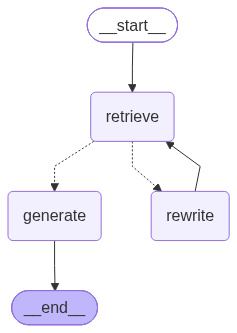

In [17]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
## initial state 세팅


initial_state = {'query': '연봉 5천만원 세금'}
graph.invoke(initial_state)

context== [Document(id='3bb2a976-0d17-42e6-8276-aab868945dcd', metadata={'source': '../documents/output_docs/income_tax.txt'}, page_content='| 1,400만원 이하               | 16퍼센트                                                            |\n| 1,400만원 초과               | 224만원 + (1,400만원 초과액 × 25퍼센트)                                  |\n| 5,000만원 이하               |                                                                     |\n| 5,000만원 초과               | 1,124만원 + (5,000만원 초과액 × 34퍼센트)                                |\n| 8,800만원 이하               |                                                                     |\n| 8,800만원 초과               | 2,416만원 + (8,800만원 초과액 × 45퍼센트)                                |\n| 1억5천만원 이하               |                                                                     |\n| 1억5천만원 초과               | 5,206만원 + (1억5천만원 초과액 × 48퍼센트)                              |\n| 3억원 이하                   |                                                           

{'query': '연봉 5천만원 세금',
 'context': [Document(id='3bb2a976-0d17-42e6-8276-aab868945dcd', metadata={'source': '../documents/output_docs/income_tax.txt'}, page_content='| 1,400만원 이하               | 16퍼센트                                                            |\n| 1,400만원 초과               | 224만원 + (1,400만원 초과액 × 25퍼센트)                                  |\n| 5,000만원 이하               |                                                                     |\n| 5,000만원 초과               | 1,124만원 + (5,000만원 초과액 × 34퍼센트)                                |\n| 8,800만원 이하               |                                                                     |\n| 8,800만원 초과               | 2,416만원 + (8,800만원 초과액 × 45퍼센트)                                |\n| 1억5천만원 이하               |                                                                     |\n| 1억5천만원 초과               | 5,206만원 + (1억5천만원 초과액 × 48퍼센트)                              |\n| 3억원 이하                   |                                 